In [16]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
%matplotlib inline

In [17]:
data = pd.read_csv("../data/mental_health_digital_behavior_data.csv")
data.head()

,daily_screen_time_min,num_app_switches,sleep_hours,notification_count,social_media_time_min,focus_score,mood_score,anxiety_level,digital_wellbeing_score
0,389.8,53,5.9,89,133.2,6.8,8.9,10.0,44.8
1,351.7,52,7.2,79,109.5,5.5,9.4,10.0,43.6
2,398.9,39,8.0,108,84.7,6.7,9.4,9.4,52.6
3,451.4,44,6.5,78,88.9,6.0,9.4,5.1,58.4
4,346.0,43,6.9,35,78.8,8.2,9.4,8.0,59.7


In [18]:
data.describe()

,daily_screen_time_min,num_app_switches,sleep_hours,notification_count,social_media_time_min,focus_score,mood_score,anxiety_level,digital_wellbeing_score
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,360.437800,49.840000,6.557400,79.51200,121.771800,6.998000,8.988600,8.451800,52.310400
std,58.782476,7.340993,1.192043,23.97974,43.809443,0.618742,0.519104,2.134425,7.943186
min,180.000000,30.000000,3.000000,20.00000,30.000000,5.500000,7.400000,1.000000,34.600000
25%,317.975000,44.000000,5.800000,63.00000,91.875000,6.600000,8.600000,7.275000,46.800000
50%,360.800000,50.000000,6.500000,80.00000,119.550000,7.000000,9.000000,9.700000,51.000000
75%,398.175000,55.000000,7.325000,96.00000,149.500000,7.400000,9.300000,10.000000,56.600000
max,591.200000,72.000000,10.000000,158.00000,296.700000,8.600000,10.000000,10.000000,80.800000


In [19]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   daily_screen_time_min    500 non-null    float64
 1   num_app_switches         500 non-null    int64  
 2   sleep_hours              500 non-null    float64
 3   notification_count       500 non-null    int64  
 4   social_media_time_min    500 non-null    float64
 5   focus_score              500 non-null    float64
 6   mood_score               500 non-null    float64
 7   anxiety_level            500 non-null    float64
 8   digital_wellbeing_score  500 non-null    float64
dtypes: float64(7), int64(2)
memory usage: 35.3 KB


In [20]:
x = data

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans

num_features = x.select_dtypes(include=["int64","float64"]).columns

preprocessor = ColumnTransformer([
    ("num",StandardScaler(),num_features)
])

In [22]:
wcss = []

for k in range(1,11):
    pipe = Pipeline([
        ("preprocessor",preprocessor),
        ("KMeans",KMeans(n_clusters=k,random_state=42))
    ])
    
    pipe.fit(x)
    
    wcss.append(pipe["KMeans"].inertia_)
    
wcss    

[4500.000000000001,
 3691.0907947315345,
 3336.2538748419447,
 3121.0950889169585,
 2962.0787176920435,
 2824.3313556892026,
 2672.3392725276917,
 2579.421395696525,
 2468.751697297145,
 2382.7990333733783]

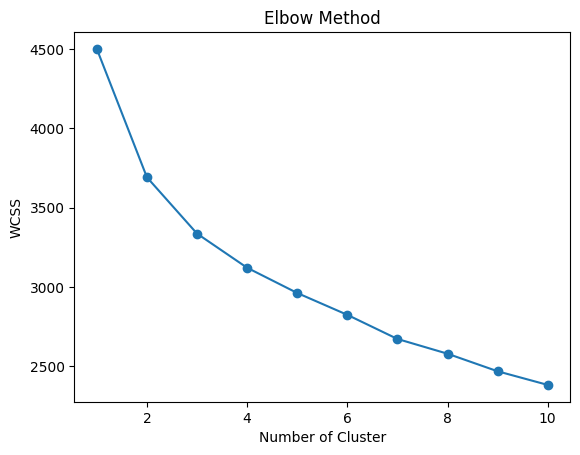

In [23]:
plt.plot(range(1,11),wcss,marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Cluster")
plt.ylabel("WCSS")
plt.show()

In [24]:
pipe = Pipeline([
    ("preprocessor",preprocessor),
    ("KMeans",KMeans(n_clusters=3,random_state=42))
])

pipe.fit(x)

cluster = pipe.predict(x)

data["cluster"] = cluster
data.head()

,daily_screen_time_min,num_app_switches,sleep_hours,notification_count,social_media_time_min,focus_score,mood_score,anxiety_level,digital_wellbeing_score,cluster
0,389.8,53,5.9,89,133.2,6.8,8.9,10.0,44.8,1
1,351.7,52,7.2,79,109.5,5.5,9.4,10.0,43.6,1
2,398.9,39,8.0,108,84.7,6.7,9.4,9.4,52.6,1
3,451.4,44,6.5,78,88.9,6.0,9.4,5.1,58.4,0
4,346.0,43,6.9,35,78.8,8.2,9.4,8.0,59.7,0


In [25]:
data.groupby("cluster").mean()

,daily_screen_time_min,num_app_switches,sleep_hours,notification_count,social_media_time_min,focus_score,mood_score,anxiety_level,digital_wellbeing_score
cluster,,,,,,,,,
0,359.852033,48.845528,6.873984,65.544715,92.630081,7.239024,9.162602,5.533333,62.962602
1,390.743564,50.623762,6.386139,91.262376,119.602970,6.586634,9.103465,9.420297,47.260891
2,325.868000,49.634286,6.532571,75.765714,144.757714,7.303429,8.733714,9.385143,50.652000


In [26]:
from sklearn.decomposition import PCA

x_preprocessed = pipe["preprocessor"].transform(x)

pca = PCA(n_components=2)

X_PCA = pca.fit_transform(x_preprocessed)

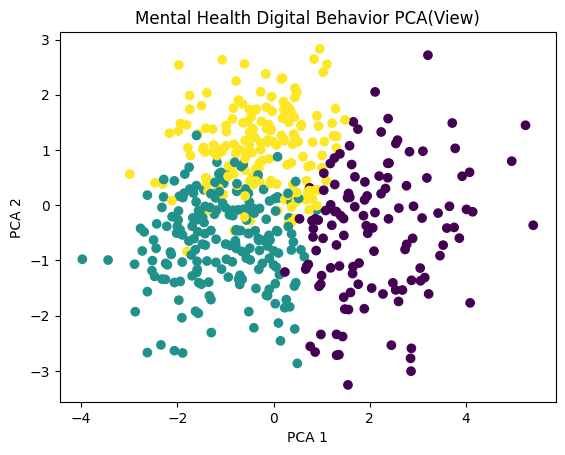

In [27]:
plt.scatter(X_PCA[:,0],X_PCA[:,1],c=cluster)
plt.title("Mental Health Digital Behavior PCA(View)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()